# Starting with the simpliest case
##### author: M.Z. 
##### date: June 30th, 2026

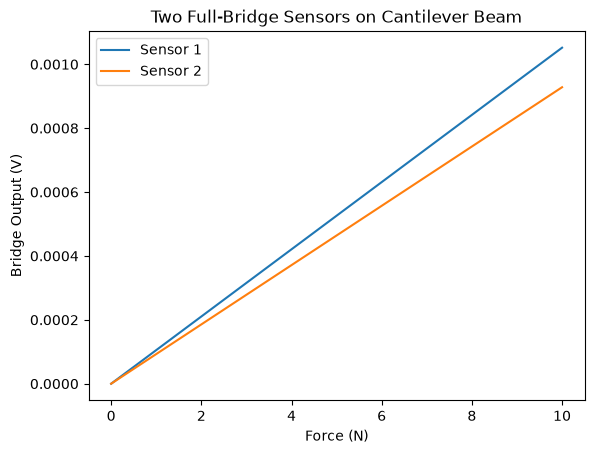

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Beam parameters
# ==============================
L = 0.02          # beam length (m)
E = 200e9        # Young's modulus (Pa) of SS
b = 0.008         # width (m)
t = 0.002        # thickness (m)

I = b * t**3 / 12   # moment of inertia of beam shape, actual design differs.
c = t / 2           # distance from neutral axis

# ==============================
# Sensor configuration
# ==============================
x1 = 0.003   # sensor 1 position (m), arbitrarily chosen to be closer to the fixed end, but can be adjusted as the current prototype is likely not the final design
x2 = 0.005   # sensor 2 position (m)

# Gauge parameters
GF = 2.0       # gauge factor
Vex = 3.3     # bridge excitation voltage (V)

# ==============================
# Full bridge model
# ==============================
def full_bridge_output(strain, GF, Vex):
    return Vex * GF * strain    # estimation, not directly modeling resistance changes in the bridge, but a simplified linear approximation

# ==============================
# Sweep force
# ==============================
forces = np.linspace(0, 10, 50)

V1s = []
V2s = []

for F in forces:
    # Strain at sensor positions (cantilever formula), but this is a tip-loaded (x = L) case
    strain1 = (F * (L - x1)) * c / (E * I)
    strain2 = (F * (L - x2)) * c / (E * I)

    # Full bridge outputs
    V1 = full_bridge_output(strain1, GF, Vex)
    V2 = full_bridge_output(strain2, GF, Vex)

    V1s.append(V1)
    V2s.append(V2)

# ==============================
# Plot results
# ==============================
plt.plot(forces, V1s, label="Sensor 1")
plt.plot(forces, V2s, label="Sensor 2")
plt.xlabel("Force (N)")
plt.ylabel("Bridge Output (V)")
plt.title("Two Full-Bridge Sensors on Cantilever Beam")
plt.legend()
plt.show()

## now with a bit noise

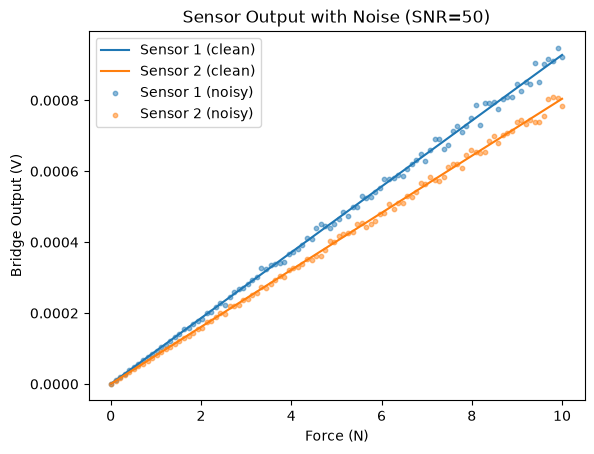

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Previously configured (unchanged)
# ==============================
# L, E, b, t, I, c, x1, x2, GF, and Vex were already set up in the earlier setup cell.
# The bridge output helper is also already defined there.

# ==============================
# Force + contact location
# ==============================
forces = np.linspace(0.01, 10, 100)  # avoid 0 (for noise scaling)
x_force = 0.018  # where force is applied (near tip)

# ==============================
# Noise settings
# ==============================
SNR = 50  # signal-to-noise ratio, boarderline case as stated by SWE

V1s = []
V2s = []
V1s_noisy = []
V2s_noisy = []

for F in forces:
    # strain based on arbitrary force location
    strain1 = (F * (x_force - x1)) * c / (E * I)
    strain2 = (F * (x_force - x2)) * c / (E * I)

    V1 = full_bridge_output(strain1, GF, Vex)
    V2 = full_bridge_output(strain2, GF, Vex)

    # Add noise
    noise1 = V1 / SNR * np.random.randn()
    noise2 = V2 / SNR * np.random.randn()

    V1s.append(V1)
    V2s.append(V2)

    V1s_noisy.append(V1 + noise1)
    V2s_noisy.append(V2 + noise2)

# ==============================
# Plot
# ==============================
plt.plot(forces, V1s, label="Sensor 1 (clean)")
plt.plot(forces, V2s, label="Sensor 2 (clean)")

plt.scatter(forces, V1s_noisy, s=10, alpha=0.5, label="Sensor 1 (noisy)")
plt.scatter(forces, V2s_noisy, s=10, alpha=0.5, label="Sensor 2 (noisy)")

plt.xlabel("Force (N)")
plt.ylabel("Bridge Output (V)")
plt.title("Sensor Output with Noise (SNR=50)")
plt.legend()
plt.show()

## under this simpliest model, how different is the estimated force as compared with the input force

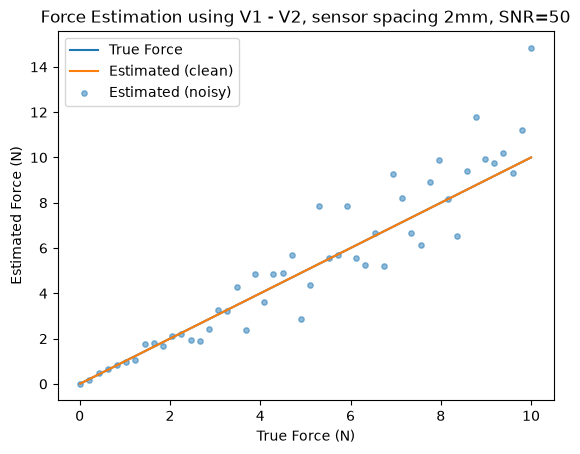

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Previously configured (unchanged)
# ==============================
# L, E, b, t, I, c, x1, x2, GF, Vex, and full_bridge_output were already set up earlier.
# Only the force sweep and reconstruction logic are being evaluated here.

# ==============================
# Force + location
# ==============================
forces = np.linspace(0.01, 10, 50)
x_force = 0.018

# ==============================
# Noise settings
# ==============================
SNR = 50

V1_clean = []
V2_clean = []
V1_noisy = []
V2_noisy = []

for F in forces:
    strain1 = (F * (x_force - x1)) * c / (E * I)
    strain2 = (F * (x_force - x2)) * c / (E * I)

    V1 = full_bridge_output(strain1, GF, Vex)
    V2 = full_bridge_output(strain2, GF, Vex)

    noise1 = V1 / SNR * np.random.randn()
    noise2 = V2 / SNR * np.random.randn()

    V1_clean.append(V1)
    V2_clean.append(V2)

    V1_noisy.append(V1 + noise1)
    V2_noisy.append(V2 + noise2)

# ==============================
# Force reconstruction: V1 - V2
# ==============================

# calibration factor (derived from model)
K = (Vex * GF * c / (E * I)) * (x2 - x1)

F_est_clean = []
F_est_noisy = []

for i in range(len(forces)):
    dV_clean = V1_clean[i] - V2_clean[i]
    dV_noisy = V1_noisy[i] - V2_noisy[i]

    F_est_clean.append(dV_clean / K)
    F_est_noisy.append(dV_noisy / K)

# ==============================
# Plot
# ==============================

plt.plot(forces, forces, label="True Force")
plt.plot(forces, F_est_clean, label="Estimated (clean)")
plt.scatter(forces, F_est_noisy, s=15, alpha=0.5, label="Estimated (noisy)")

plt.xlabel("True Force (N)")
plt.ylabel("Estimated Force (N)")
plt.title("Force Estimation using V1 - V2, sensor spacing 2mm, SNR=50")
plt.legend()
plt.show()

### Increasing the sensor distance to see how that impacts estimated force

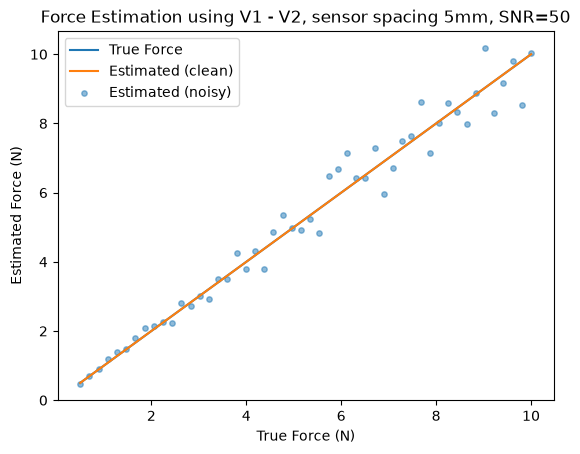

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Previously configured (unchanged)
# ==============================
# L, E, b, t, I, c, x1, GF, Vex, and full_bridge_output were already set up earlier.
# Only the spacing-specific update is being evaluated here.

# ==============================
# Sensor spacing update
# ==============================
x2 = 0.008  # updated second sensor position for the 5 mm spacing case

# ==============================
# Force + location
# ==============================
forces = np.linspace(0.5, 10, 50)
x_force = 0.018

# ==============================
# Noise settings
# ==============================
SNR = 50

V1_clean = []
V2_clean = []
V1_noisy = []
V2_noisy = []

for F in forces:
    strain1 = (F * (x_force - x1)) * c / (E * I)
    strain2 = (F * (x_force - x2)) * c / (E * I)

    V1 = full_bridge_output(strain1, GF, Vex)
    V2 = full_bridge_output(strain2, GF, Vex)

    noise1 = V1 / SNR * np.random.randn()
    noise2 = V2 / SNR * np.random.randn()

    V1_clean.append(V1)
    V2_clean.append(V2)

    V1_noisy.append(V1 + noise1)
    V2_noisy.append(V2 + noise2)

# ==============================
# Force reconstruction: V1 - V2
# ==============================

# calibration factor (derived from model)
K = (Vex * GF * c / (E * I)) * (x2 - x1)

F_est_clean = []
F_est_noisy = []

for i in range(len(forces)):
    dV_clean = V1_clean[i] - V2_clean[i]
    dV_noisy = V1_noisy[i] - V2_noisy[i]

    F_est_clean.append(dV_clean / K)
    F_est_noisy.append(dV_noisy / K)

# ==============================
# Plot
# ==============================

plt.plot(forces, forces, label="True Force")
plt.plot(forces, F_est_clean, label="Estimated (clean)")
plt.scatter(forces, F_est_noisy, s=15, alpha=0.5, label="Estimated (noisy)")

plt.xlabel("True Force (N)")
plt.ylabel("Estimated Force (N)")
plt.title("Force Estimation using V1 - V2, sensor spacing 5mm, SNR=50")
plt.legend()
plt.show()

### Force error decreases with sensor spacing

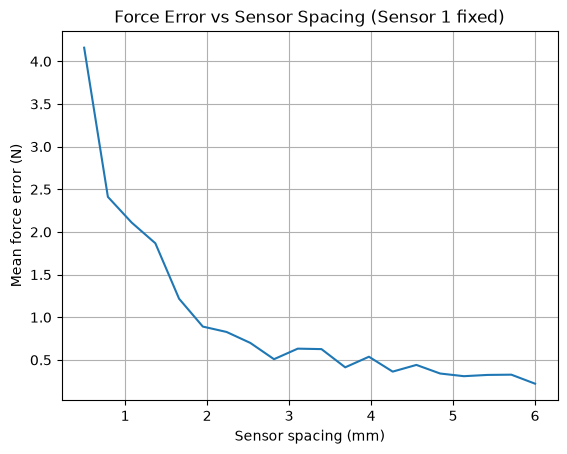

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Previously configured (unchanged)
# ==============================
# L, E, b, t, I, c, x1, GF, Vex, and full_bridge_output were already set up earlier.
# Only the spacing sweep logic is modified in this cell.

# ==============================
# Fixed sensor
# ==============================
# x1 = 0.003   # fixed sensor position, already configured earlier

# ==============================
# Force + location
# ==============================
forces = np.linspace(0.5, 10, 40)
x_force = 0.018

# ==============================
# Noise model
# ==============================
noise_floor = 5e-6
noise_prop = 1/50

# ==============================
# Sweep spacing
# ==============================
spacings = np.linspace(0.0005, 0.006, 20)

mean_errors = []

for d in spacings:
    x2 = x1 + d   # moving sensor

    F_errors = []

    # calibration (VERY important)
    K = (Vex * GF * c / (E * I)) * (x2 - x1)

    for F in forces:
        strain1 = (F * (x_force - x1)) * c / (E * I)
        strain2 = (F * (x_force - x2)) * c / (E * I)

        V1 = full_bridge_output(strain1, GF, Vex)
        V2 = full_bridge_output(strain2, GF, Vex)

        # noise (realistic)
        noise1 = noise_floor*np.random.randn() + V1*noise_prop*np.random.randn()
        noise2 = noise_floor*np.random.randn() + V2*noise_prop*np.random.randn()

        V1n = V1 + noise1
        V2n = V2 + noise2

        # force estimation
        F_est = (V1n - V2n) / K

        F_errors.append(abs(F_est - F))

    mean_errors.append(np.mean(F_errors))

# ==============================
# Plot
# ==============================
plt.plot(spacings*1000, mean_errors)
plt.xlabel("Sensor spacing (mm)")
plt.ylabel("Mean force error (N)")
plt.title("Force Error vs Sensor Spacing (Sensor 1 fixed)")
plt.grid()
plt.show()

### a better mems style model

in a real MEMS bridge, the four piezoresistors should not react the same way. When a beam bends, one side goes into tension and the other goes into compression. So the bridge needs some arms to move one way and some to move the other way.

That is the whole point of the differential readout. The output is the difference between them, not the sum. If everything were signed the same way, the bridge would mostly cancel itself out and the signal would be weak.

In a gripper, if the object is near the tip and the jaws close, the beam can bend in a way that makes the top surface go into compression and the bottom surface into tension. If the beam bends the other way, those signs flip. So the important thing is not “top is always tension” or “bottom is always compression,” but that the two sides of the bridge see opposite signs for the same bending event.

For the 0°/90° versus 45°/45° question: for a simple bending beam, 0°/90° is usually the more obvious layout because it lines up with the main strain directions. 45°/45° is more useful when the strain direction is less clear or when shear matters more.


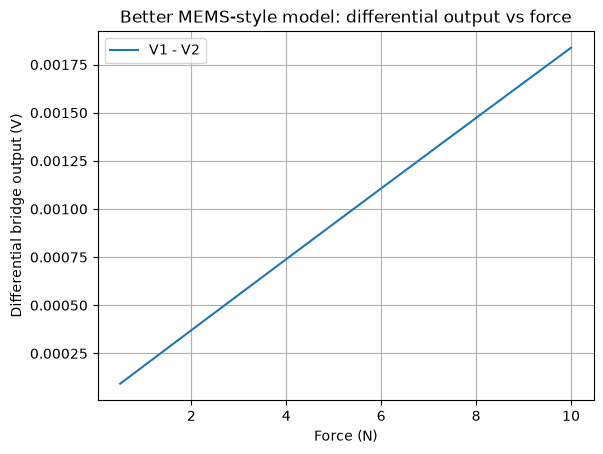

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Better MEMS-style model
# ==============================
L = 0.02
E = 200e9
b = 0.008
t = 0.002
nu = 0.3

I = b * t**3 / 12
c = t / 2

x1 = 0.003
x2 = 0.006
x_force = 0.018

R0 = 350
GF = 2.0
Vex = 3.3

forces = np.linspace(0.5, 10, 40)

# MEMS internal amplification and gradient parameters
G = 20
h_mem = 50e-6


def beam_strain(F, x):
    return (F * (x_force - x)) * c / (E * I)


def mems_bridge_output(eps, G=G, h_mem=h_mem):
    """Single-surface MEMS bridge with internal strain gradient.

    A realistic MEMS strain-gauge bridge should not place all four gauges with the
    same signed strain sensitivity. In a real die, neighboring gauges are usually
    oriented so that one arm sees a positive strain change while the opposite arm
    sees a negative strain change. That is what makes the Wheatstone bridge output
    respond to bending instead of cancelling out.
    """
    # Mechanical strain is amplified by the MEMS flexure before it reaches the
    # piezoresistive elements embedded in the membrane.
    eps0 = G * eps

    # Internal gauge-height pattern for a physically realistic single-surface bridge.
    # The signs are intentionally asymmetric so adjacent arms see opposite-signed
    # strain contributions. If the pattern were perfectly symmetric, the bridge
    # would be locally balanced and the differential output would collapse to zero.
    y = np.array([-0.5, 0.5, 0.5, -0.5]) * h_mem
    kappa = eps0 / max(h_mem, 1e-12)
    eps_local = eps0 + kappa * y

    R1 = R0 * (1 + GF * eps_local[0])
    R2 = R0 * (1 + GF * eps_local[1])
    R3 = R0 * (1 + GF * eps_local[2])
    R4 = R0 * (1 + GF * eps_local[3])

    # Differential bridge output: a real MEMS sensor relies on the two halves of
    # the bridge seeing opposite resistance changes to generate a nonzero output.
    return Vex * ((R2 / (R1 + R2)) - (R4 / (R3 + R4)))


Vdiff = []
for F in forces:
    eps1 = beam_strain(F, x1)
    eps2 = beam_strain(F, x2)
    V1 = mems_bridge_output(eps1)
    V2 = mems_bridge_output(eps2)
    Vdiff.append(V1 - V2)

plt.plot(forces, Vdiff, label="V1 - V2")
plt.xlabel("Force (N)")
plt.ylabel("Differential bridge output (V)")
plt.title("Better MEMS-style model: differential output vs force")
plt.grid()
plt.legend()
plt.show()

### New simulation: two-sensor differential output for different force magnitudes and locations

The next cell sweeps both force magnitude and contact position along the beam. The purpose is to see how the differential output changes when the same force is applied at different places, which is really the point of the two-sensor model.

Understading
- The heatmap is a response surface. It shows that the differential signal depends on both force and location, but it does not automatically mean that one scalar output can uniquely recover both of them.
- If only use one scalar such as $V_1 - V_2$, then generally cannot cleanly separate “small force far away” from “larger force closer in” without some extra assumption or calibration.
- If use the two raw sensor outputs $V_1$ and $V_2$, then there are two measurements, and in principle that is more informative. In a known model, those two values can be used to fit both force and location more realistically. But this is still not a perfect inverse problem; the geometry and noise matter a lot.
- So the current two-sensor setup is useful, but it is a practical way to get more information rather than a guaranteed perfect force-and-location decoder.


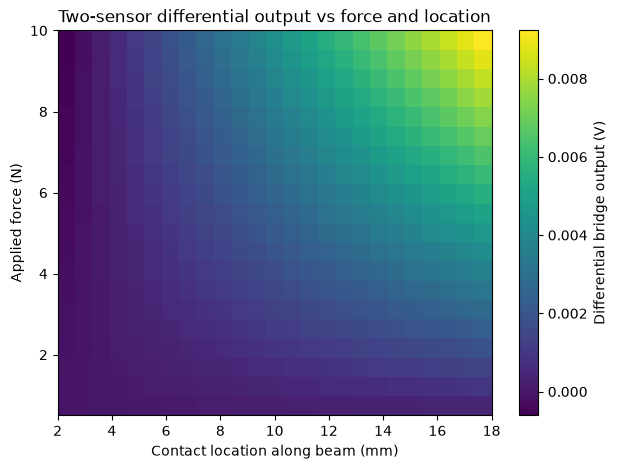

True force = 4.000 N, true location = 12.000 mm
Estimated force = 3.987 N, estimated location = 11.950 mm
Observed V1 = 0.003704 V, V2 = 0.001484 V
Best-fit V1 = 0.003692 V, V2 = 0.001491 V


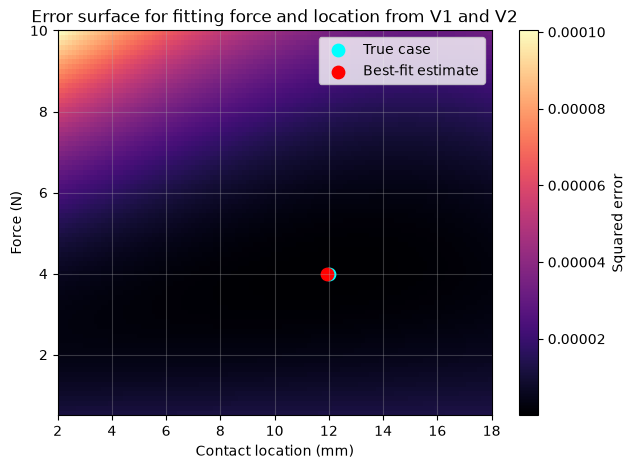

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Two-sensor differential simulation: force vs location
# ==============================

L = 0.02
E = 200e9
b = 0.008
t = 0.002
I = b * t**3 / 12
c = t / 2

x_ref = 0.003      # reference sensor location
x_force = 0.018    # force application point on the beam

R0 = 350
GF = 2.0
Vex = 3.3
G = 20
h_mem = 50e-6

forces = np.linspace(0.5, 10, 20)
locations = np.linspace(0.002, 0.018, 25)


def beam_strain(F, x):
    return (F * (x_force - x)) * c / (E * I)


def mems_bridge_output(eps, G=G, h_mem=h_mem):
    eps0 = G * eps
    y = np.array([-0.5, 0.5, 0.5, -0.5]) * h_mem
    kappa = eps0 / max(h_mem, 1e-12)
    eps_local = eps0 + kappa * y

    R1 = R0 * (1 + GF * eps_local[0])
    R2 = R0 * (1 + GF * eps_local[1])
    R3 = R0 * (1 + GF * eps_local[2])
    R4 = R0 * (1 + GF * eps_local[3])

    return Vex * ((R2 / (R1 + R2)) - (R4 / (R3 + R4)))

# Differential output for the two-sensor model
Vmap = np.zeros((len(forces), len(locations)))
for i, F in enumerate(forces):
    for j, x_loc in enumerate(locations):
        eps_ref = beam_strain(F, x_ref)
        eps_loc = beam_strain(F, x_loc)
        V_ref = mems_bridge_output(eps_ref)
        V_loc = mems_bridge_output(eps_loc)
        Vmap[i, j] = V_ref - V_loc

plt.figure(figsize=(7, 5))
plt.imshow(
    Vmap,
    aspect='auto',
    origin='lower',
    extent=[locations[0]*1000, locations[-1]*1000, forces[0], forces[-1]],
    cmap='viridis',
)
plt.colorbar(label='Differential bridge output (V)')
plt.xlabel('Contact location along beam (mm)')
plt.ylabel('Applied force (N)')
plt.title('Two-sensor differential output vs force and location')
plt.grid(False)
plt.show()

# ==============================
# Inverse fit: from observed V1 and V2 to force and location
### Inverse problem: recover force and contact location from $V_1$ and $V_2$

# This section flips the problem around. Instead of sweeping force and location to see the output, I choose a known true case, compute the two sensor outputs $V_1$ and $V_2$, and then search the model space to see which force and location best reproduce those outputs.

# If the model is known and the measurements are clean, this is a simple two-unknowns, two-measurements problem. In practice, noise and model error make it less perfect, but this is the basic idea.

# ==============================

# Choose a true case to recover
true_force = 4.0
true_location = 0.012

# Compute the corresponding sensor outputs from the model
true_eps_ref = beam_strain(true_force, x_ref)
true_eps_loc = beam_strain(true_force, true_location)
V1_true = mems_bridge_output(true_eps_ref)
V2_true = mems_bridge_output(true_eps_loc)

# Build a coarse grid search over force and location
force_grid = np.linspace(0.5, 10, 80)
location_grid = np.linspace(0.002, 0.018, 120)

error_map = np.zeros((len(force_grid), len(location_grid)))
best_error = np.inf
best_F = None
best_x = None
best_V1 = None
best_V2 = None

for i, F in enumerate(force_grid):
    for j, x_loc in enumerate(location_grid):
        eps_ref = beam_strain(F, x_ref)
        eps_loc = beam_strain(F, x_loc)
        V1_pred = mems_bridge_output(eps_ref)
        V2_pred = mems_bridge_output(eps_loc)
        diff = (V1_pred - V1_true)**2 + (V2_pred - V2_true)**2
        error_map[i, j] = diff
        if diff < best_error:
            best_error = diff
            best_F = F
            best_x = x_loc
            best_V1 = V1_pred
            best_V2 = V2_pred

print(f'True force = {true_force:.3f} N, true location = {true_location*1000:.3f} mm')
print(f'Estimated force = {best_F:.3f} N, estimated location = {best_x*1000:.3f} mm')
print(f'Observed V1 = {V1_true:.6f} V, V2 = {V2_true:.6f} V')
print(f'Best-fit V1 = {best_V1:.6f} V, V2 = {best_V2:.6f} V')

# ==============================
# Visualization: error surface and best-fit point
# ==============================
fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(
    error_map,
    aspect='auto',
    origin='lower',
    extent=[location_grid[0]*1000, location_grid[-1]*1000, force_grid[0], force_grid[-1]],
    cmap='magma',
)
plt.colorbar(im, ax=ax, label='Squared error')

ax.scatter(true_location*1000, true_force, color='cyan', s=80, label='True case')
ax.scatter(best_x*1000, best_F, color='red', s=80, label='Best-fit estimate')
ax.set_xlabel('Contact location (mm)')
ax.set_ylabel('Force (N)')
ax.set_title('Error surface for fitting force and location from V1 and V2')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


### inverse fit x10 to check for accuracy

SNR used for evaluation = 50
Mean |F_est - F_true| = 0.0751 N
Median |F_est - F_true| = 0.0800 N
RMSE force = 0.0909 N
Mean |x_est - x_true| = 0.064 mm
Median |x_est - x_true| = 0.053 mm
RMSE location = 0.079 mm
Fraction within 10% force error = 90.00%
Fraction within 1 mm location error = 100.00%


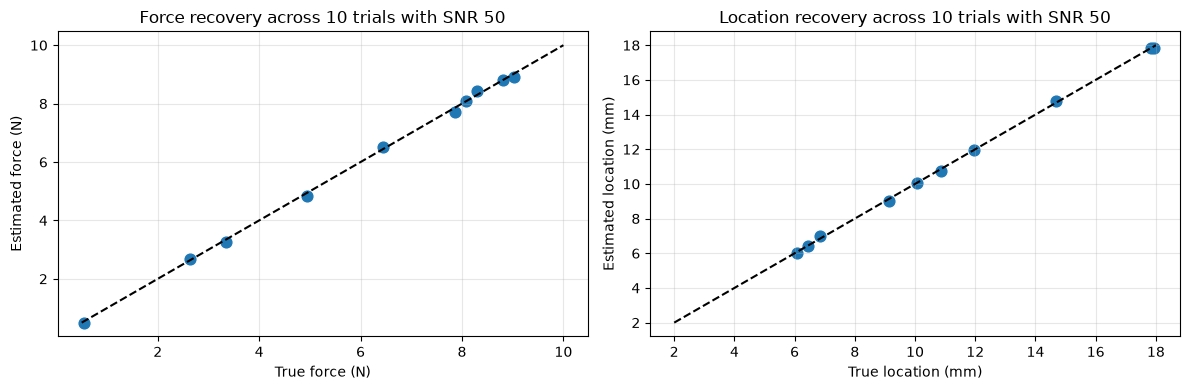

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Repeat the inverse fit over multiple true cases with measurement noise
# ==============================

rng = np.random.default_rng(7)
n_trials = 10
SNR = 50

true_forces = rng.uniform(0.5, 10.0, n_trials)
true_locations = rng.uniform(0.002, 0.018, n_trials)

L = 0.02
E = 200e9
b = 0.008
t = 0.002
I = b * t**3 / 12
c = t / 2

x_ref = 0.003
x_force = 0.018

R0 = 350
GF = 2.0
Vex = 3.3
G = 20
h_mem = 50e-6


def beam_strain(F, x):
    return (F * (x_force - x)) * c / (E * I)


def mems_bridge_output(eps, G=G, h_mem=h_mem):
    eps0 = G * eps
    y = np.array([-0.5, 0.5, 0.5, -0.5]) * h_mem
    kappa = eps0 / max(h_mem, 1e-12)
    eps_local = eps0 + kappa * y

    R1 = R0 * (1 + GF * eps_local[0])
    R2 = R0 * (1 + GF * eps_local[1])
    R3 = R0 * (1 + GF * eps_local[2])
    R4 = R0 * (1 + GF * eps_local[3])

    return Vex * ((R2 / (R1 + R2)) - (R4 / (R3 + R4)))


force_grid = np.linspace(0.5, 10, 80)
location_grid = np.linspace(0.002, 0.018, 120)

est_forces = []
est_locations = []
force_errors = []
location_errors = []

for idx in range(n_trials):
    F_true = true_forces[idx]
    x_true = true_locations[idx]

    V1_true = mems_bridge_output(beam_strain(F_true, x_ref))
    V2_true = mems_bridge_output(beam_strain(F_true, x_true))

    # Add measurement noise at SNR = 50
    noise1 = V1_true / SNR * np.random.randn()
    noise2 = V2_true / SNR * np.random.randn()
    V1_obs = V1_true + noise1
    V2_obs = V2_true + noise2

    best_error = np.inf
    best_F = None
    best_x = None

    for F in force_grid:
        for x_loc in location_grid:
            V1_pred = mems_bridge_output(beam_strain(F, x_ref))
            V2_pred = mems_bridge_output(beam_strain(F, x_loc))
            diff = (V1_pred - V1_obs) ** 2 + (V2_pred - V2_obs) ** 2
            if diff < best_error:
                best_error = diff
                best_F = F
                best_x = x_loc

    est_forces.append(best_F)
    est_locations.append(best_x)
    force_errors.append(abs(best_F - F_true))
    location_errors.append(abs(best_x - x_true) * 1000)

est_forces = np.array(est_forces)
est_locations = np.array(est_locations)
force_errors = np.array(force_errors)
location_errors = np.array(location_errors)

print(f"SNR used for evaluation = {SNR}")
print(f"Mean |F_est - F_true| = {np.mean(force_errors):.4f} N")
print(f"Median |F_est - F_true| = {np.median(force_errors):.4f} N")
print(f"RMSE force = {np.sqrt(np.mean(force_errors**2)):.4f} N")
print(f"Mean |x_est - x_true| = {np.mean(location_errors):.3f} mm")
print(f"Median |x_est - x_true| = {np.median(location_errors):.3f} mm")
print(f"RMSE location = {np.sqrt(np.mean(location_errors**2)):.3f} mm")
print(f"Fraction within 10% force error = {np.mean(force_errors / true_forces < 0.05):.2%}")
print(f"Fraction within 1 mm location error = {np.mean(location_errors < 1.0):.2%}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(true_forces, est_forces, s=60)
ax[0].plot([0.5, 10], [0.5, 10], 'k--')
ax[0].set_xlabel('True force (N)')
ax[0].set_ylabel('Estimated force (N)')
ax[0].set_title('Force recovery across 10 trials with SNR 50')
ax[0].grid(alpha=0.3)

ax[1].scatter(true_locations * 1000, est_locations * 1000, s=60)
ax[1].plot([2, 18], [2, 18], 'k--')
ax[1].set_xlabel('True location (mm)')
ax[1].set_ylabel('Estimated location (mm)')
ax[1].set_title('Location recovery across 10 trials with SNR 50')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Case Comparison
- A is the simplest case: one bridge sensing one location. It is useful as a baseline, but it is very local. A small force near the sensor and a bigger force farther away can look similar.
- B is the two-sensor differential case. Two sensors at different places give a second reading, and the difference between them carries more information than a single reading by itself.
- C is the dual-beam gripper idea. In the gripper, two flexures or beams can bend in opposite directions under the same grasping action, so the structure itself creates the kind of opposite-signed strain that the bridge wants to see.

The two-sensor setup is important here. Without it, a single reading is not enough to distinguish a small force applied close to the sensor from a larger force applied farther away.

And for the specific C_dual expression, in a perfectly symmetric model, it is basically the same differential idea as B, just implemented with a sign flip. In other words, if the two sides are symmetric and the bridge response is linear, then C_dual is essentially twice the magnitude of the corresponding differential signal from B, just with the sign convention shifted.




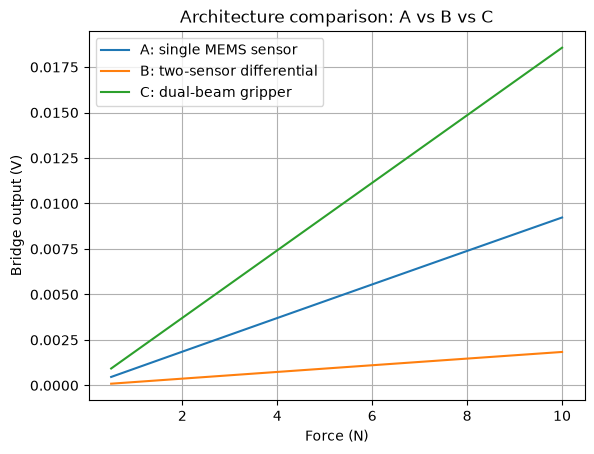

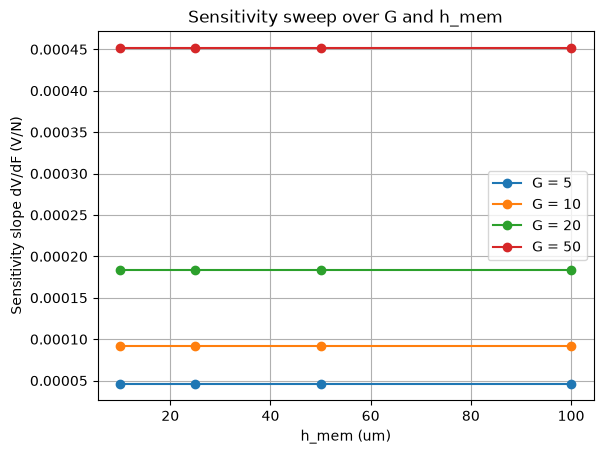

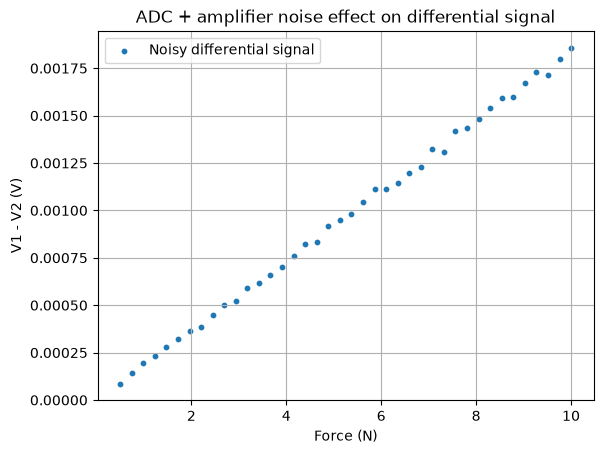

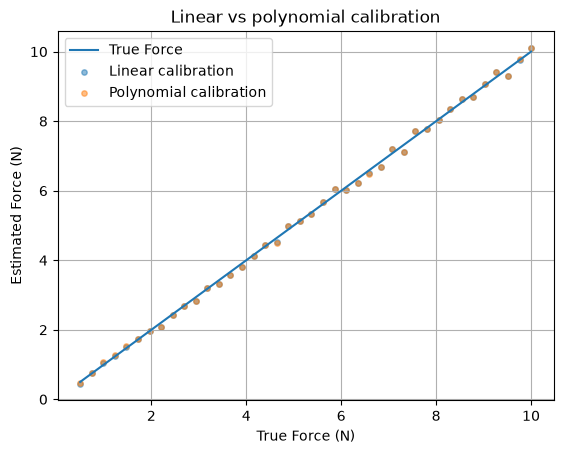

In [19]:
# ==============================
# A. Single MEMS sensor comparison (A vs B vs C)
# ==============================

# The three cases below are meant to illustrate three different sensing strategies:
# - A: one bridge on one beam location, which gives a single local reading.
# - B: two sensors at different positions, using their difference to infer force and
#   location more robustly.
# - C: a dual-beam gripper-style concept, where two beams bend in opposite directions
#   so that the differential signal is amplified by geometry rather than by a simple
#   pair of point sensors.

L = 0.02
E = 200e9
b = 0.008
t = 0.002
I = b * t**3 / 12
c = t / 2

x_force = 0.018
forces = np.linspace(0.5, 10, 40)

x1 = 0.003
x2 = 0.006
x_A = x1
x_B = x2
x_C = 0.009

R0 = 350
GF = 2.0
Vex = 3.3
G = 20
h_mem = 50e-6


def beam_strain(F, x):
    return (F * (x_force - x)) * c / (E * I)


def mems_bridge_output(eps, G=G, h_mem=h_mem):
    eps0 = G * eps
    y = np.array([-0.5, 0.5, 0.5, -0.5]) * h_mem
    kappa = eps0 / max(h_mem, 1e-12)
    eps_local = eps0 + kappa * y

    R1 = R0 * (1 + GF * eps_local[0])
    R2 = R0 * (1 + GF * eps_local[1])
    R3 = R0 * (1 + GF * eps_local[2])
    R4 = R0 * (1 + GF * eps_local[3])

    return Vex * ((R2 / (R1 + R2)) - (R4 / (R3 + R4)))


def architecture_response(x):
    return np.array([mems_bridge_output(beam_strain(F, x)) for F in forces])

A_single = architecture_response(x_A)
B_diff = np.array([mems_bridge_output(beam_strain(F, x1)) - mems_bridge_output(beam_strain(F, x2)) for F in forces])
C_dual = np.array([
    mems_bridge_output(beam_strain(F, x1)) - mems_bridge_output(-beam_strain(F, x1))
    for F in forces
])

plt.figure()
plt.plot(forces, A_single, label="A: single MEMS sensor")
plt.plot(forces, B_diff, label="B: two-sensor differential")
plt.plot(forces, C_dual, label="C: dual-beam gripper")
plt.xlabel("Force (N)")
plt.ylabel("Bridge output (V)")
plt.title("Architecture comparison: A vs B vs C")
plt.legend()
plt.grid()
plt.show()

# ==============================
# B. Sweep G and h_mem for sensitivity analysis
# ==============================
G_values = np.array([5, 10, 20, 50])
h_mem_values = np.array([10e-6, 25e-6, 50e-6, 100e-6])

sensitivity_map = []
for G in G_values:
    row = []
    for h_mem in h_mem_values:
        Vdiff_list = []
        for F in forces:
            eps1 = beam_strain(F, x1)
            eps2 = beam_strain(F, x2)
            V1 = mems_bridge_output(eps1, G=G, h_mem=h_mem)
            V2 = mems_bridge_output(eps2, G=G, h_mem=h_mem)
            Vdiff_list.append(V1 - V2)
        slope, _ = np.polyfit(forces, Vdiff_list, 1)
        row.append(slope)
    sensitivity_map.append(row)

sensitivity_map = np.array(sensitivity_map)

plt.figure()
for i, G in enumerate(G_values):
    plt.plot(h_mem_values * 1e6, sensitivity_map[i], marker='o', label=f'G = {G}')

plt.xlabel("h_mem (um)")
plt.ylabel("Sensitivity slope dV/dF (V/N)")
plt.title("Sensitivity sweep over G and h_mem")
plt.legend()
plt.grid()
plt.show()

# ==============================
# C. Add ADC quantization and amplifier noise
# ==============================
adc_bits = 32
adc_fullscale = 3.3
adc_lsb = adc_fullscale / (2**(adc_bits-1))
amp_noise_rms = 5e-6
noise_prop = 1/50

Vdiff_clean = []
Vdiff_noisy = []
for F in forces:
    eps1 = beam_strain(F, x1)
    eps2 = beam_strain(F, x2)
    V1 = mems_bridge_output(eps1)
    V2 = mems_bridge_output(eps2)
    Vdiff = V1 - V2

    amp = amp_noise_rms * np.random.randn()
    quant = adc_lsb * np.random.normal(0, 1)
    prop = Vdiff * noise_prop * np.random.randn()

    Vdiff_clean.append(Vdiff)
    Vdiff_noisy.append(Vdiff + amp + quant + prop)

plt.figure()
plt.scatter(forces, Vdiff_noisy, s=10, label="Noisy differential signal")
plt.xlabel("Force (N)")
plt.ylabel("V1 - V2 (V)")
plt.title("ADC + amplifier noise effect on differential signal")
plt.grid()
plt.legend()
plt.show()

# ==============================
# D. Compare linear vs polynomial calibration
# ==============================
Vdiff_clean = np.array(Vdiff_clean)
Vdiff_noisy = np.array(Vdiff_noisy)

linear_cal = np.polyfit(Vdiff_clean, forces, 1)
poly_cal = np.polyfit(Vdiff_clean, forces, 3)

F_lin = np.polyval(linear_cal, Vdiff_noisy)
F_poly = np.polyval(poly_cal, Vdiff_noisy)

plt.figure()
plt.plot(forces, forces, label="True Force")
plt.scatter(forces, F_lin, s=15, alpha=0.5, label="Linear calibration")
plt.scatter(forces, F_poly, s=15, alpha=0.5, label="Polynomial calibration")
plt.xlabel("True Force (N)")
plt.ylabel("Estimated Force (N)")
plt.title("Linear vs polynomial calibration")
plt.legend()
plt.grid()
plt.show()